# Learning to Throw Against the Current: Internal Models of Object-Environment Dynamics

### **Highlights**
* We developed a novel, ecologically grounded VR task in which compensating for a water current required adjusting both launch angle and speed within a complex solution space.
* Participants formed a robust internal model of the projectile–current interaction, as evidenced by clear aftereffects during still-water washout.
* Prior experience with the current improved initial performance on novel, adjacent targets, and stronger currents scaled the amount of adaptation without altering generalization or washout patterns.

### **Justification Statement**
Most sensorimotor learning paradigms rely on arbitrary visuomotor or force-field transformations applied to the limb or cursor, offering limited insight into how learning unfolds when environmental dynamics act on manipulated objects. Understanding how people adapt to ecologically meaningful environmental perturbations—such as forces that continuously alter a projectile's trajectory—is therefore essential for understanding how humans adapt to dynamic external contexts. Our study addresses this gap by examining how humans learn and generalize under dynamic projectile-environment interactions, making it relevant for NCM’s focus on the neural control of movement in naturalistic and behaviorally grounded contexts.

**Theme:** Adaption and Plasticity in Motor Control

---

### **Abstract**

Adaptation is typically studied using perturbations applied directly to the limb or cursor. Yet in everyday action, adaptation involves compensating for the physical impacts of inferred, but often uncertain environmental dynamics acting on manipulated objects, an aspect often overlooked in traditional sensorimotor adaptation paradigms. To examine how people learn under more realistic object–environment interactions, we designed a novel virtual reality task where participants launched a virtual ball across a dynamic, lateral water current to spatially distinct targets. The velocity of the current (2.0 m/s or 3.0 m/s) was manipulated to test how the scale of this perturbation influences learning. Because the current introduces a constant lateral force on the ball’s flight, compensation depends on the non-linear interactions between launch angle and speed. This results in a spatially dependent, redundant solution space, creating a more complex control problem than standard visuomotor rotation tasks.

A physics-based simulation defined each target’s solution space—the set of launch angle–speed combinations that result in a hit under each current velocity. Upstream targets exhibited narrower solution spaces due to the opposing current, whereas downstream targets had broader solution spaces and thus permitted more flexible control policies. Learning was quantified as the lateral miss distance (cm) between the projectile and target at the point of closest approach. To test whether people form an internal representation of the water current, we examined whether improvement on one set of targets would generalize to novel, adjacent targets that impose different solution spaces.

During the task, participants launched a projectile toward four targets. Targets were presented in a blocked design, starting with a Training phase (current on) with one upstream-downstream pair of targets, followed by an alternating no-current Washout phase to assess aftereffects and retention. This Training-Washout sequence was then repeated for a second, spatially shifted pair of targets. This allowed us to measure generalization by comparing experienced participants during the second Training phase against naive performance on the same targets.

Our findings revealed that participants developed a robust internal model of the projectile–environment interaction, as evidenced by a reduction in errors and significant aftereffects during Washout across all groups. Between-group comparisons revealed that learning transferred to novel targets, whereby participants with prior experience compensating for the current showed significantly lower initial errors for novel targets compared to naive participants on the same targets. Finally, the magnitude of the environmental perturbation significantly scaled the extent of adaptation, such that adaptation was larger under the higher velocity current. Despite the differences in adaptive gain, the pattern of generalization and performance during Washout (no-current trials) remained similar.

Together, these results show that people rapidly form internal models under altered projectile–environment dynamics, and that prior experience drives spatially tuned generalization. These results provide insight into the mechanisms underlying sensorimotor adaptation for changing object–environment dynamics, suggesting the brain forms an internal model representing the physics of the environment.

# 

# Load Data & Formatting

In [1]:
# import key libraries
library(lme4)
library(emmeans)
library(dplyr)
library(afex)
library(ggplot2)

# full dataset

# set working directory & load FULL data from local storage
setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
df_full <- read.csv("PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv")


# Format data types 
df_full$ppid_full <- factor(df_full$ppid_full)
df_full$speed_label <- factor(df_full$speed_label)
df_full$target_x_label <- factor(df_full$target_x_label)
df_full$phase <- factor(df_full$phase)
# ensure consistent levels
df_full$target_x_label <- factor(df_full$target_x_label, 
                                 levels = c("L60", "L30", "R30", "R60"))



# load the smaller, early late (first and last 4 trials) dataset
df_early_late_4 <- read.csv("early_late_4_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Format data types 
df_early_late_4$ppid_full <- factor(df_early_late_4$ppid_full)
df_early_late_4$speed_label <- factor(df_early_late_4$speed_label)
df_early_late_4$target_x_label <- factor(df_early_late_4$target_x_label)
df_early_late_4$phase <- factor(df_early_late_4$phase)
# ensure consistent levels
df_early_late_4$target_x_label <- factor(df_early_late_4$target_x_label, 
                                     levels = c("L60", "L30", "R30", "R60"))


# load the smaller, early late (first and last 2 trials) dataset
df_early_late_2 <- read.csv("early_late_2_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Format data types 
df_early_late_2$ppid_full <- factor(df_early_late_2$ppid_full)
df_early_late_2$speed_label <- factor(df_early_late_2$speed_label)
df_early_late_2$target_x_label <- factor(df_early_late_2$target_x_label)
df_early_late_2$phase <- factor(df_early_late_2$phase)
# ensure consistent levels
df_early_late_2$target_x_label <- factor(df_early_late_2$target_x_label, 
                                     levels = c("L60", "L30", "R30", "R60"))


Warning message:
"package 'lme4' was built under R version 4.4.3"
Loading required package: Matrix

Warning message:
"package 'emmeans' was built under R version 4.4.3"
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'afex' was built under R version 4.4.3"
************
Welcome to afex. For support visit: http://afex.singmann.science/

- Functions for ANOVAs: aov_car(), aov_ez(), and aov_4()
- Methods for calculating p-values with mixed(): 'S', 'KR', 'LRT', and 'PB'
- 'afex_aov' and 'mixed' objects can be passed to emmeans() for follow-up tests
- Get and set global package options with: afex_options()
- Set sum-to-zero contrasts globally: set_sum_contrasts()
- For example analyses see: browseVignett

# Overall learning (early vs late)

First and Last 4 trials


ANALYSIS FOR SPEED: -3 


Contrasts set to contr.sum for the following variables: target_x_label



Anova Table (Type 3 tests)

Response: flip_min_distance_xPCA_mean_bc
                    Effect    df    MSE         F  ges p.value
1           target_x_label 3, 86 774.28 25.99 *** .401   <.001
2                trial_set 1, 86 274.03 71.09 *** .178   <.001
3 target_x_label:trial_set 3, 86 274.03    2.29 + .020    .084
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1
Interaction Not significant. Skipping post-hocs for Water Speed Condition -3 

ANALYSIS FOR SPEED: -2 


Contrasts set to contr.sum for the following variables: target_x_label



Anova Table (Type 3 tests)

Response: flip_min_distance_xPCA_mean_bc
                    Effect    df    MSE         F  ges p.value
1           target_x_label 3, 72 371.80 23.66 *** .378   <.001
2                trial_set 1, 72 230.11 40.55 *** .177   <.001
3 target_x_label:trial_set 3, 72 230.11    3.65 * .055    .017
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1

--- Post-Hoc Comparisons ---
target_x_label = L60:
 contrast     estimate   SE df t.ratio p.value
 early - late    10.32 4.80 72   2.151  0.0349

target_x_label = L30:
 contrast     estimate   SE df t.ratio p.value
 early - late     5.88 5.06 72   1.163  0.2487

target_x_label = R30:
 contrast     estimate   SE df t.ratio p.value
 early - late    19.13 4.80 72   3.987  0.0002

target_x_label = R60:
 contrast     estimate   SE df t.ratio p.value
 early - late    27.44 5.06 72   5.427  <.0001



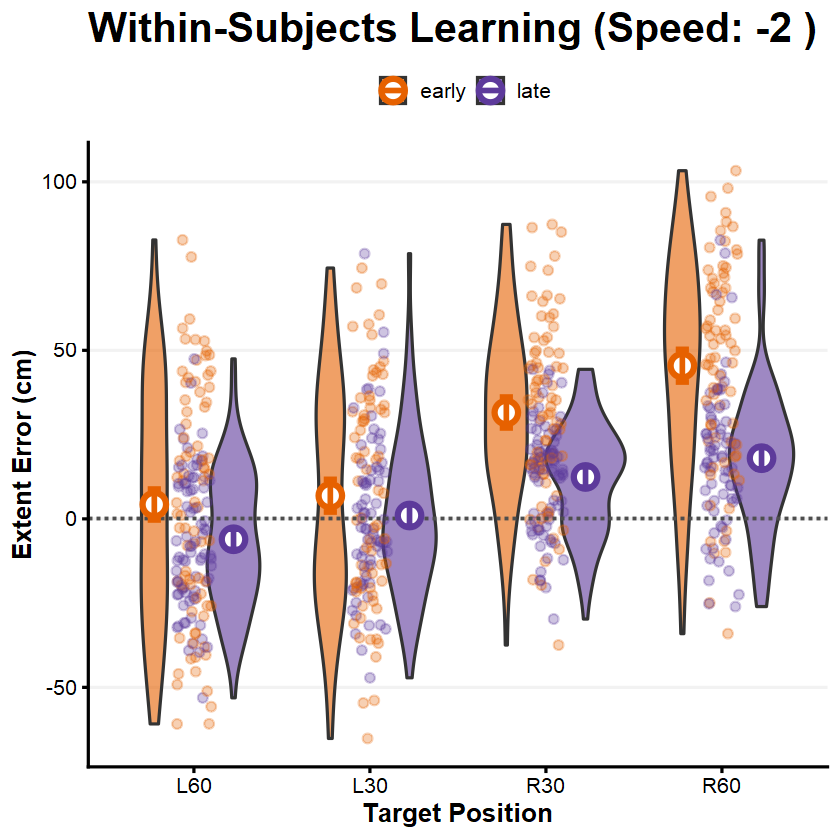

In [5]:
# Isolate training phase
df_early_late_4_t1 <- df_early_late_4[df_early_late_4$phase == 'training_1',]
speeds_list <- unique(df_early_late_4_t1$speed_label)

# --- Iterative Analysis & Visualization ---
for (s in speeds_list) {
  
  cat("\n========================================\n")
  cat("ANALYSIS FOR SPEED:", s, "\n")
  cat("========================================\n")
  
  df_subset <- df_early_late_4_t1[df_early_late_4_t1$speed_label == s,]
  df_subset <- droplevels(df_subset) 
  
  # Dummy ID to force "Between-Subjects" treatment of target_x_label
  df_subset$strict_id <- paste(df_subset$ppid_full, df_subset$target_x_label, sep="_")
  
  # Run the Mixed ANOVA
  model <- aov_ez(
    id = "strict_id",              
    dv = "flip_min_distance_xPCA_mean_bc",                  
    data = df_subset,                
    between = "target_x_label",    
    within = "trial_set",
    fun_aggregate = mean 
  )
  
  print(model)

  # Grab p-value
  p_val_interaction <- model$anova_table["target_x_label:trial_set", "Pr(>F)"]

  # Conditional logic for post-hocs 
  if (p_val_interaction <= 0.05) {
      
      # Post-hoc Comparisons (Early vs Late per Target)
      cat("\n--- Post-Hoc Comparisons ---\n")
      post_hocs <- emmeans(model, ~ trial_set | target_x_label)
      print(pairs(post_hocs))
      
      # Extract EMMs for Plotting
      emm_for_plot <- as.data.frame(emmeans(model, ~ trial_set * target_x_label))


        # --- Emmeans per Target Visualization ---
      adaptation_plot <- ggplot(df_subset, aes(x = target_x_label, y = flip_min_distance_xPCA_mean_bc, fill = trial_set)) +
        
        # Layer 1: Violin plots for distribution
        geom_violin(alpha = 0.6, position = position_dodge(width = 0.9)) +
        
        # Layer 2: Raw data points
        geom_jitter(aes(color = trial_set),
                    alpha = 0.3, size = 2,
                    position = position_jitter(width = 0.1, height = 0)) +
        
        # Layer 3: Baseline
        geom_hline(yintercept = 0, linetype = "dashed", color = "grey30", linewidth = 0.8) +
        
        # Layer 4: Mean points from ANOVA
        geom_point(data = emm_for_plot, 
                   aes(x = target_x_label, y = emmean, color = trial_set),
                   size = 5, stroke = 2, fill = "white", shape = 21,
                   position = position_dodge(width = 0.9)) +
        
        # Layer 5: Error bars from ANOVA
        geom_errorbar(data = emm_for_plot,
                      aes(x = target_x_label, y = emmean, color = trial_set,
                          ymin = emmean - SE, ymax = emmean + SE),
                      width = 0.15, linewidth = 1.2,
                      position = position_dodge(width = 0.9)) +
        
        scale_fill_manual(values = c("early" = "#E66100", "late" = "#5D3A9B"),
                          labels = c("training_1" = "Naive", "training_2" = "Experienced")) +
        
        scale_color_manual(values = c("early" = "#E66100", "late" = "#5D3A9B"),
                           labels = c("trial_set" = "Naive", "training_2" = "Experienced")) +
        
        theme_classic(base_size = 15) + 
        labs(
          title = paste("Within-Subjects Learning (Speed:", s, ")"),
          x = "Target Position",
          y = "Extent Error (cm)",
          fill = "",
          color = ""
        ) +
        theme(
          legend.position = "top",
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold", size = 24),
          panel.grid.major.y = element_line(color = "grey95"),
          axis.text = element_text(color = "black")
        )
    
      print(adaptation_plot)

      
  } else {
      cat("Interaction Not significant. Skipping post-hocs for Water Speed Condition", s, "\n")
      next
  }
  
}

Here we compare the mean extent error along primary axis for the first and last four trials per target (seperate for each water speed condition). 

Speed 3.0 m/s
- While marginal (p=0.069), no significant interaction was observed.
- A significant main effect of target suggests that the extent of errors varied across targets. Given, the breadth of the solution space (combination of launch velocities resulting in a hit) varied across targets this was expected. 
- A significant main effect of trial set demonstrates a significant difference between early and late training, independent of target location.

Speed 2.0 m/s
- A significant interaction was observed, suggesting that errors from early to late training differed significantly across targets in T1 (Training Phase 1). This could be driven by neglegible changes in the "easier" downstream targets (i.e., those with larger solution spaces) resulting in less room for improvement compared to robust adaptation demonstrated in the more challenging, upstream targets. 

First and Last 2 trials

In [3]:
# Isolate training phase
df_early_late_2_t1 <- df_early_late_2[df_early_late_2$phase == 'training_1',]
speeds_list <- unique(df_early_late_2_t1$speed_label)

# --- Iterative Analysis & Visualization ---
for (s in speeds_list) {
  
  cat("\n========================================\n")
  cat("ANALYSIS FOR SPEED:", s, "\n")
  cat("========================================\n")
  
  df_subset <- df_early_late_2_t1[df_early_late_2_t1$speed_label == s,]
  df_subset <- droplevels(df_subset) 
  
  # Dummy ID to force "Between-Subjects" treatment of target_x_label
  df_subset$strict_id <- paste(df_subset$ppid_full, df_subset$target_x_label, sep="_")
  
  # Run the Mixed ANOVA
  model <- aov_ez(
    id = "strict_id",              
    dv = "flip_min_distance_xPCA_mean_bc",                  
    data = df_subset,                
    between = "target_x_label",    
    within = "trial_set",
    fun_aggregate = mean 
  )
  
  print(model)

  # Grab p-value
  p_val_interaction <- model$anova_table["target_x_label:trial_set", "Pr(>F)"]

  # Conditional logic for post-hocs 
  if (p_val_interaction <= 0.05) {
      
      # Post-hoc Comparisons (Early vs Late per Target)
      cat("\n--- Post-Hoc Comparisons ---\n")
      post_hocs <- emmeans(model, ~ trial_set | target_x_label)
      print(pairs(post_hocs))
      
      # Extract EMMs for Plotting
      emm_for_plot <- as.data.frame(emmeans(model, ~ trial_set * target_x_label))


        # --- Emmeans per Target Visualization ---
      adaptation_plot <- ggplot(df_subset, aes(x = target_x_label, y = flip_min_distance_xPCA_mean_bc, fill = trial_set)) +
        
        # Layer 1: Violin plots for distribution
        geom_violin(alpha = 0.6, position = position_dodge(width = 0.9)) +
        
        # Layer 2: Raw data points
        geom_jitter(aes(color = trial_set),
                    alpha = 0.3, size = 2,
                    position = position_jitter(width = 0.1, height = 0)) +
        
        # Layer 3: Baseline
        geom_hline(yintercept = 0, linetype = "dashed", color = "grey30", linewidth = 0.8) +
        
        # Layer 4: Mean points from ANOVA
        geom_point(data = emm_for_plot, 
                   aes(x = target_x_label, y = emmean, color = trial_set),
                   size = 5, stroke = 2, fill = "white", shape = 21,
                   position = position_dodge(width = 0.9)) +
        
        # Layer 5: Error bars from ANOVA
        geom_errorbar(data = emm_for_plot,
                      aes(x = target_x_label, y = emmean, color = trial_set,
                          ymin = emmean - SE, ymax = emmean + SE),
                      width = 0.15, linewidth = 1.2,
                      position = position_dodge(width = 0.9)) +
        
        scale_fill_manual(values = c("early" = "#E66100", "late" = "#5D3A9B"),
                          labels = c("training_1" = "Naive", "training_2" = "Experienced")) +
        
        scale_color_manual(values = c("early" = "#E66100", "late" = "#5D3A9B"),
                           labels = c("trial_set" = "Naive", "training_2" = "Experienced")) +
        
        theme_classic(base_size = 15) + 
        labs(
          title = paste("Within-Subjects Learning (Speed:", s, ")"),
          x = "Target Position",
          y = "Extent Error (cm)",
          fill = "",
          color = ""
        ) +
        theme(
          legend.position = "top",
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold", size = 24),
          panel.grid.major.y = element_line(color = "grey95"),
          axis.text = element_text(color = "black")
        )
    
      print(adaptation_plot)

      
  } else {
      cat("Interaction Not significant. Skipping post-hocs for Water Speed Condition", s, "\n")
      next
  }
  
}


ANALYSIS FOR SPEED: -3 


Contrasts set to contr.sum for the following variables: target_x_label



Anova Table (Type 3 tests)

Response: flip_min_distance_xPCA_mean_bc
                    Effect    df    MSE          F  ges p.value
1           target_x_label 3, 86 813.17  22.69 *** .349   <.001
2                trial_set 1, 86 389.71 101.22 *** .276   <.001
3 target_x_label:trial_set 3, 86 389.71       1.58 .018    .200
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1
Interaction Not significant. Skipping post-hocs for Water Speed Condition -3 

ANALYSIS FOR SPEED: -2 


Contrasts set to contr.sum for the following variables: target_x_label



Anova Table (Type 3 tests)

Response: flip_min_distance_xPCA_mean_bc
                    Effect    df    MSE         F  ges p.value
1           target_x_label 3, 72 409.64 16.59 *** .261   <.001
2                trial_set 1, 72 393.91 61.74 *** .296   <.001
3 target_x_label:trial_set 3, 72 393.91      1.25 .025    .298
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1
Interaction Not significant. Skipping post-hocs for Water Speed Condition -2 


# Between-Subjects Transfer


--- RUNNING BETWEEN-BETWEEN TRANSFER ANALYSIS FOR SPEED: -2 ---


Contrasts set to contr.sum for the following variables: target_x_label, phase



Anova Table (Type 3 tests)

Response: flip_PCA_extent_error_cm_mean_bc
                Effect     df    MSE         F  ges p.value
1       target_x_label 3, 586 687.66 53.74 *** .216   <.001
2                phase 1, 586 687.66 31.02 *** .050   <.001
3 target_x_label:phase 3, 586 687.66      1.81 .009    .144
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1
Interaction Not significant. Skipping post-hocs for Water Speed Condition -2 

--- RUNNING BETWEEN-BETWEEN TRANSFER ANALYSIS FOR SPEED: -3 ---


Contrasts set to contr.sum for the following variables: target_x_label, phase



Anova Table (Type 3 tests)

Response: flip_PCA_extent_error_cm_mean_bc
                Effect     df    MSE          F  ges p.value
1       target_x_label 3, 656 718.93  91.45 *** .295   <.001
2                phase 1, 656 718.93 131.53 *** .167   <.001
3 target_x_label:phase 3, 656 718.93    4.47 ** .020    .004
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1

--- Post-Hoc Comparisons (Transfer) ---
target_x_label = L60:
 contrast                estimate   SE  df t.ratio p.value
 training_1 - training_2     24.1 4.18 656   5.770  <.0001

target_x_label = L30:
 contrast                estimate   SE  df t.ratio p.value
 training_1 - training_2     13.3 4.15 656   3.206  0.0014

target_x_label = R30:
 contrast                estimate   SE  df t.ratio p.value
 training_1 - training_2     35.2 4.31 656   8.168  <.0001

target_x_label = R60:
 contrast                estimate   SE  df t.ratio p.value
 training_1 - training_2     23.9 4.19 656   5.703  <.0001



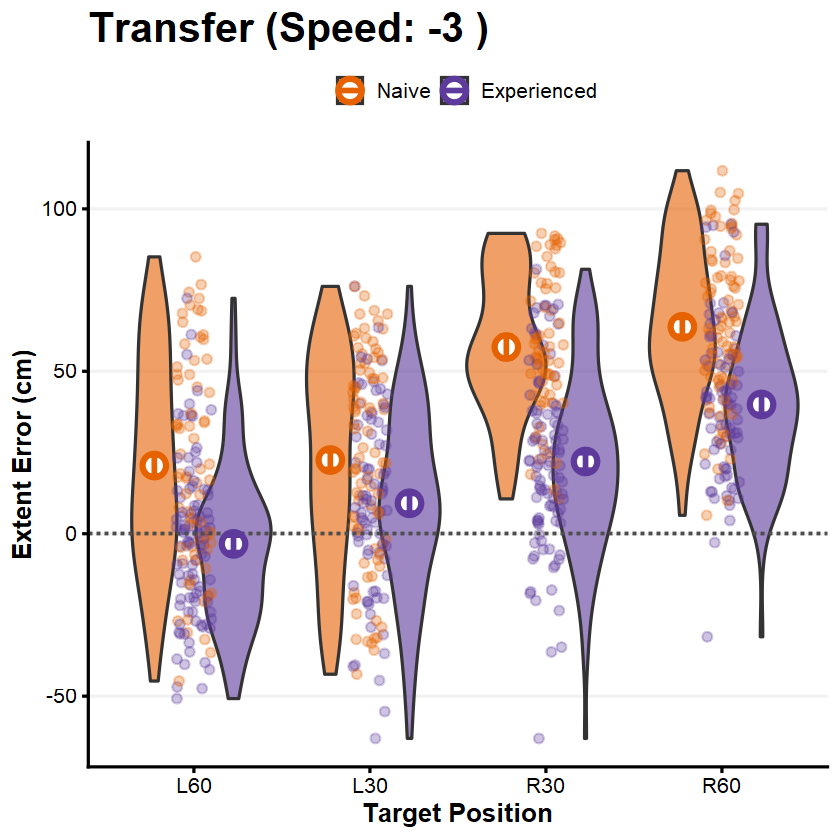

In [13]:

# Filter for Transfer (Early trials only)
df_transfer <- df_early_late_4[df_early_late_4$trial_set == 'early',]
df_transfer$phase <- factor(df_transfer$phase, levels = c("training_1", "training_2"))

speeds_list <- unique(df_transfer$speed_label)

for (s in speeds_list) {
  
  cat("\n--- RUNNING BETWEEN-BETWEEN TRANSFER ANALYSIS FOR SPEED:", s, "---\n")
  
  df_subset <- df_transfer[df_transfer$speed_label == s,]
  df_subset <- droplevels(df_subset) 

  # Unique ID for EVERY observation to allow Between-Between execution
  df_subset$unique_obs_id <- seq_len(nrow(df_subset))
  
  # Run the ANOVA: Both factors in between
  # This prevents listwise deletion due to missing pairs
  model <- aov_ez(
    id = "unique_obs_id",              
    dv = "flip_PCA_extent_error_cm_mean_bc",                  
    data = df_subset,                
    between = c("target_x_label", "phase"), 
    fun_aggregate = mean 
  )
  
  print(model)


  # Grab p-value
  p_val_interaction <- model$anova_table["target_x_label:phase", "Pr(>F)"]

  # Conditional logic for post-hocs 
  if (p_val_interaction <= 0.05) {

      
      # Post-hoc Comparisons (Phase 1 vs Phase 2 per Target)
      cat("\n--- Post-Hoc Comparisons (Transfer) ---\n")
      post_hocs <- emmeans(model, ~ phase | target_x_label)
      print(pairs(post_hocs))
      
      # Extract EMMs for Plotting
      emm_for_plot <- as.data.frame(emmeans(model, ~ phase * target_x_label))
      
      # --- 3. Visualization (Violin Plot) ---
      adaptation_plot <- ggplot(df_subset, aes(x = target_x_label, y = flip_PCA_extent_error_cm_mean_bc, fill = phase)) +
        
        # Layer 1: Violin plots for distribution
        geom_violin(alpha = 0.6, position = position_dodge(width = 0.9)) +
        
        # Layer 2: Raw data points
        geom_jitter(aes(color = phase),
                    alpha = 0.3, size = 2,
                    position = position_jitter(width = 0.1, height = 0)) +
        
        # Layer 3: Baseline
        geom_hline(yintercept = 0, linetype = "dashed", color = "grey30", linewidth = 0.8) +
        
        # Layer 4: Mean points from ANOVA
        geom_point(data = emm_for_plot, 
                   aes(x = target_x_label, y = emmean, color = phase),
                   size = 5, stroke = 2, fill = "white", shape = 21,
                   position = position_dodge(width = 0.9)) +
        
        # Layer 5: Error bars from ANOVA
        geom_errorbar(data = emm_for_plot,
                      aes(x = target_x_label, y = emmean, color = phase,
                          ymin = emmean - SE, ymax = emmean + SE),
                      width = 0.15, linewidth = 1.2,
                      position = position_dodge(width = 0.9)) +
        
        scale_fill_manual(values = c("training_1" = "#E66100", "training_2" = "#5D3A9B"),
                          labels = c("training_1" = "Naive", "training_2" = "Experienced")) +
        
        scale_color_manual(values = c("training_1" = "#E66100", "training_2" = "#5D3A9B"),
                           labels = c("training_1" = "Naive", "training_2" = "Experienced")) +
        
        theme_classic(base_size = 15) + 
        labs(
          title = paste("Transfer (Speed:", s, ")"),
          x = "Target Position",
          y = "Extent Error (cm)",
          fill = "",
          color = ""
        ) +
        theme(
          legend.position = "top",
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold", size = 24),
          panel.grid.major.y = element_line(color = "grey95"),
          axis.text = element_text(color = "black")
        )
    
      print(adaptation_plot)

  } else {
      cat("Interaction Not significant. Skipping post-hocs for Water Speed Condition", s, "\n")
      next
  }
  
}

Here we compare the mean extent error along primary axis for the first four trials per target (seperate for each water speed condition) across T1 AND T2. This analysis compares early performance in T1 (naive state) to early performance in T2 (experienced state) at identical target locations. 

Significant error reductions in T2 demonstrates transfer, where experienced participants successfully apply a previously learned compensation to a novel context (i.e., target). 